In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

#### Functions

In [2]:
def plot_frequency(df, str_col):
    # freq
    ser_freq = df[str_col].value_counts(normalize=True)
    df_freq = ser_freq.reset_index()
    df_freq.columns = [str_col, 'Proportion']
    df_freq.sort_values(by=str_col, ascending=False, inplace=True)

    # plot
    x = df_freq[str_col]
    y = df_freq['Proportion']
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Proportion {str_col} (N = {int_nrows})')
    ax.set_xlabel(str_col)
    ax.set_ylabel('Proportion')
    bars = ax.bar(x, y)
    ax.bar_label(bars, fmt='%.4f')

    # show
    plt.show()

In [3]:
def plot_distribution(df, str_col):
    list_tmp = list(df[str_col])
    int_n = len(list_tmp)
    flt_mn = np.mean(list_tmp)
    flt_mdn = np.median(list_tmp)
    str_title = f"""
    Distribution of {str_col} (N = {int_n})
    Mn = {flt_mn:0.4f}; Mdn = {flt_mdn:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    sns.kdeplot(list_tmp, ax=ax)
    # show
    plt.show()

In [4]:
def plot_dv_by_iv(df, str_col_dv, str_col_iv):
    int_nrows = df.shape[0]
    # unique vals for iv
    list_str_val = list(df[str_col_iv].unique())
    # plot
    str_title = f'Distribution of {str_col_dv} by {str_col_iv} (N = {int_nrows})'
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col_dv)
    for str_val in tqdm(list_str_val):
        # subset
        df_tmp = df[df[str_col_iv] == str_val].copy()
        # list tmp
        list_tmp = list(df_tmp[str_col_dv])
        int_n = len(list_tmp)
        flt_mn = np.mean(list_tmp)
        flt_mdn = np.median(list_tmp)
        str_label = f'{str_val}: N={int_n}; Mn={flt_mn:0.2f}; Mdn={flt_mdn:0.2f}'
        # plot
        sns.kdeplot(list_tmp, label=str_label, ax=ax)
    # legend
    plt.legend()
    # show
    plt.show()

#### Constants

In [5]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

list_str_iv = [
    'ENG-bk',
    'ENG-franchise',
    'ENG-franchise-bk',
]

Project: 20241112-simple-model-test


#### Import data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df = pd.read_parquet(str_uri)
# set dtm
df['request_datetime'] = pd.to_datetime(df['request_datetime'])
# show
df

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:283: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,linkf206__tu,linkf207__tu,linkf208__tu,linkf209__tu,linkf210__tu,linkf211__tu,linkf212__tu,linkf213__tu,totalincome__app,totaldebt__app
0,8439574,2024-12-03 08:40:04+00:00,PRESTIGE-GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8564134,2025-01-14 07:37:54+00:00,PRESTIGE-GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8489707,2024-12-15 06:08:17+00:00,PRESTIGE-GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,0.0,235.0,0.0,4.0,0.0,1005.0,0.0,0.48,NaN,NaN
0,8554640,2025-01-10 05:31:51+00:00,PRESTIGE-GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425624,2024-11-26 22:41:51+00:00,PRESTIGE-GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0.0,0.0,0.0,0.0,7.0,0.0,1166.0,0.95,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8574699,2025-01-18 02:42:42+00:00,PRESTIGE-GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8528513,2024-12-29 04:14:24+00:00,PRESTIGE-GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8506878,2024-12-19 02:10:09+00:00,PRESTIGE-GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Date range

In [7]:
dtm_min = df['request_datetime'].min()
dtm_max = df['request_datetime'].max()
print(f'Date range: {dtm_min} - {dtm_max}')

Date range: 2024-11-26 07:10:23+00:00 - 2025-01-21 06:57:02+00:00


#### BK tag

In [8]:
df['ENG-bk'] = df['intopenbktype__app'].apply(
    lambda x: 'BK' if pd.notnull(x) else 'No BK',
)

#### Franchise tag

In [9]:
df['ENG-franchise'] = df['strdealershiptrackertype__app'].apply(
    lambda x: 'Franchise' if x != 'Independent' else 'Independent',
)

#### Franchise-BK

In [10]:
df['ENG-franchise-bk'] = df.apply(
    lambda x: 'Franchise-BK' if (x['ENG-franchise'] == 'Franchise') & (x['ENG-bk'] == 'BK') else 'No Franchise-BK',
    axis=1,
)

#### LTV

In [11]:
# amt financed
df['amtfinanced__app'] = df['amtfinanced__app'].replace(0, np.nan)
# book value
df['bookvalue__app'] = df['bookvalue__app'].replace(0, np.nan)
# LTV
df['ENG-loan_to_value'] = df['amtfinanced__app'] / df['bookvalue__app']
# impute
df['ENG-loan_to_value'] = df['ENG-loan_to_value'].fillna(1.2734844012832087)
# clip
df['ENG-loan_to_value'] = df['ENG-loan_to_value'].clip(upper=2)

#### Income

In [12]:
df['fltgrossmonthly__income_sum'] = df['fltgrossmonthly__income_sum'].fillna(0)
df['fltgrossmonthly__income_sum'] = df['fltgrossmonthly__income_sum'].clip(upper=11742.160000000047)

#### Miles

In [13]:
df['miles_odometer__app'] = df['miles_odometer__app'].replace(0, np.nan)
df['miles_odometer__app'] = df['miles_odometer__app'].fillna(60518.520779948754)
df['miles_odometer__app'] = df['miles_odometer__app'].clip(upper=200000)

#### Income at debtor level

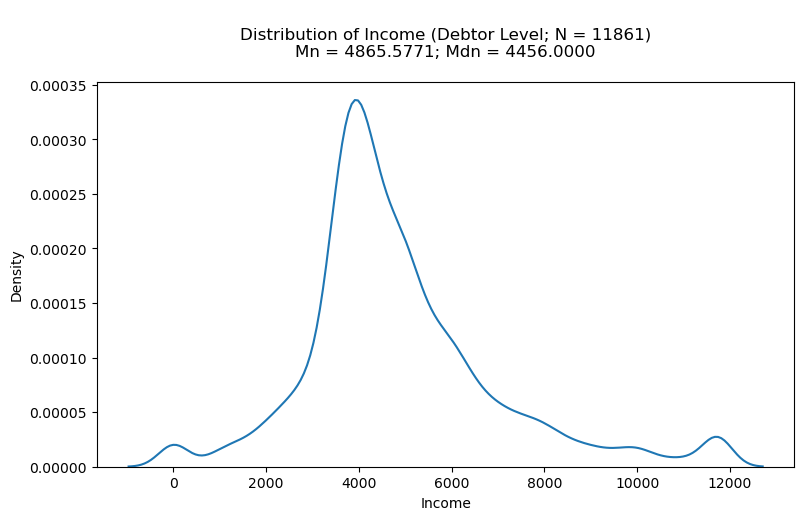

In [14]:
list_tmp = list(df['fltgrossmonthly__income_sum'])
int_n = len(list_tmp)
flt_mn = np.mean(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of Income (Debtor Level; N = {int_n})
Mn = {flt_mn:0.4f}; Mdn = {flt_mdn:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Income')
sns.kdeplot(list_tmp, ax=ax)
# show
plt.show()

#### Group

In [15]:
# group
df = df.groupby(by='accountid', as_index=False).agg({
    'ENG-bk': 'first',
    'ENG-franchise': 'first',
    'ENG-franchise-bk': 'first',
    'ENG-loan_to_value': 'first',
    'fltgrossmonthly__income_sum': 'sum',
    'miles_odometer__app': 'first',
})
int_nrows = df.shape[0]
# show
df

,accountid,ENG-bk,ENG-franchise,ENG-franchise-bk,ENG-loan_to_value,fltgrossmonthly__income_sum,miles_odometer__app
0,5782431,No BK,Franchise,No Franchise-BK,1.273484,4502.38,77837.0
1,8292595,No BK,Franchise,No Franchise-BK,0.501786,7056.00,57677.0
2,8300223,BK,Franchise,Franchise-BK,0.994140,10860.53,42128.0
3,8303160,No BK,Independent,No Franchise-BK,1.193988,3501.31,74484.0
4,8306424,No BK,Independent,No Franchise-BK,1.212453,11605.52,59650.0
...,...,...,...,...,...,...,...
9995,8582527,No BK,Franchise,No Franchise-BK,1.318922,3587.00,70054.0
9996,8582538,No BK,Independent,No Franchise-BK,0.998997,3890.00,53654.0
9997,8582546,No BK,Independent,No Franchise-BK,1.250000,4100.00,41221.0
9998,8582550,No BK,Franchise,No Franchise-BK,0.967072,11000.00,154978.0


#### Frequency plot

  0%|          | 0/3 [00:00<?, ?it/s]

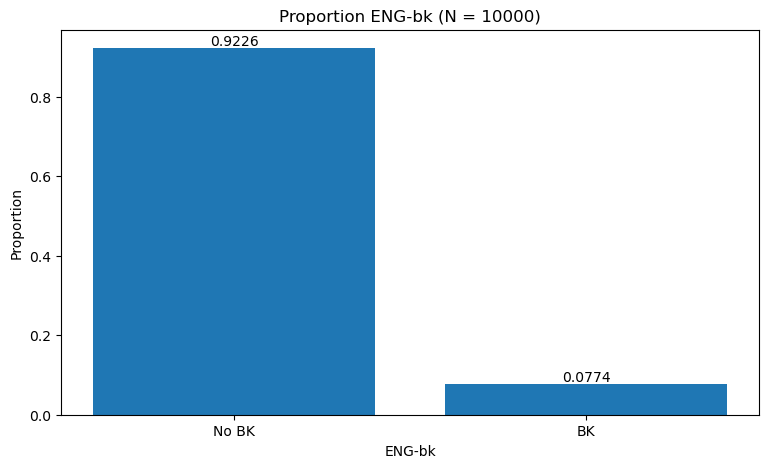

 33%|███▎      | 1/3 [00:00<00:00,  9.80it/s]

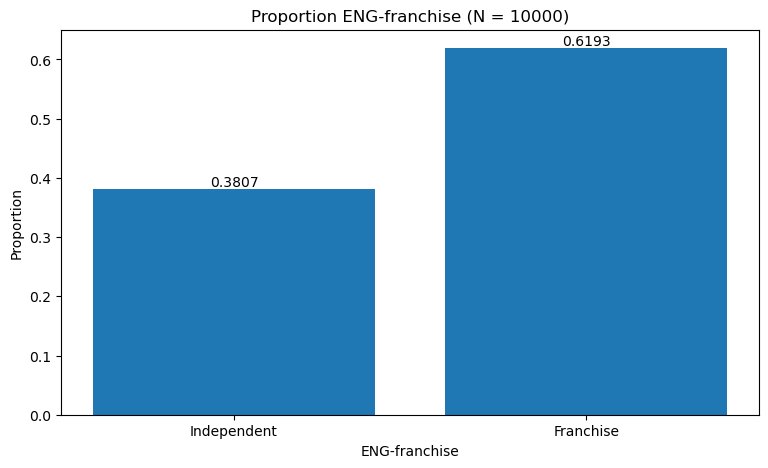

 67%|██████▋   | 2/3 [00:00<00:00,  9.09it/s]

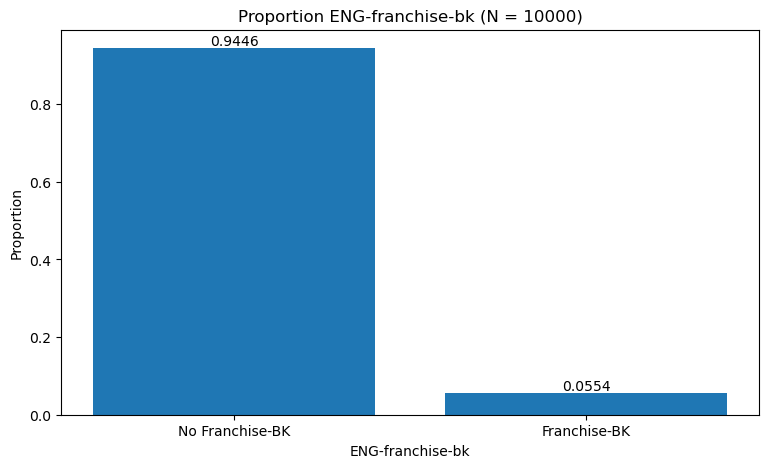

100%|██████████| 3/3 [00:00<00:00,  9.12it/s]


In [16]:
list_str_col = [
    'ENG-bk',
    'ENG-franchise',
    'ENG-franchise-bk',
]
for str_col in tqdm(list_str_col):
    plot_frequency(
        df=df,
        str_col=str_col,
    )

#### LTV

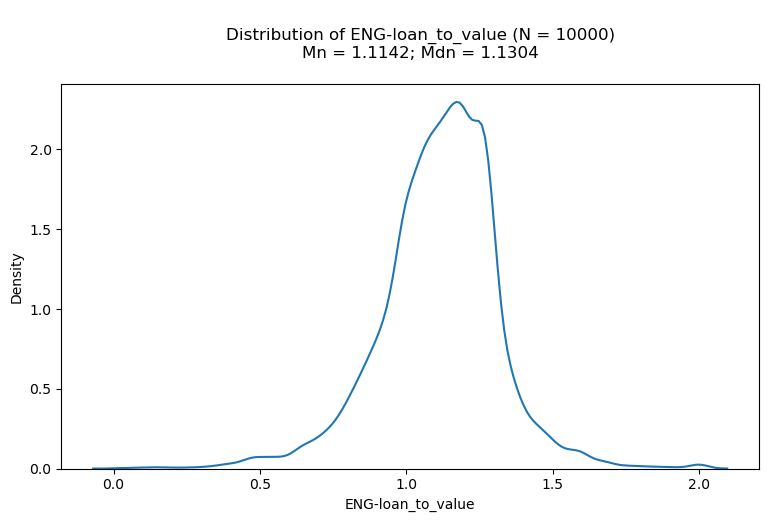

100%|██████████| 2/2 [00:00<00:00, 22.03it/s]


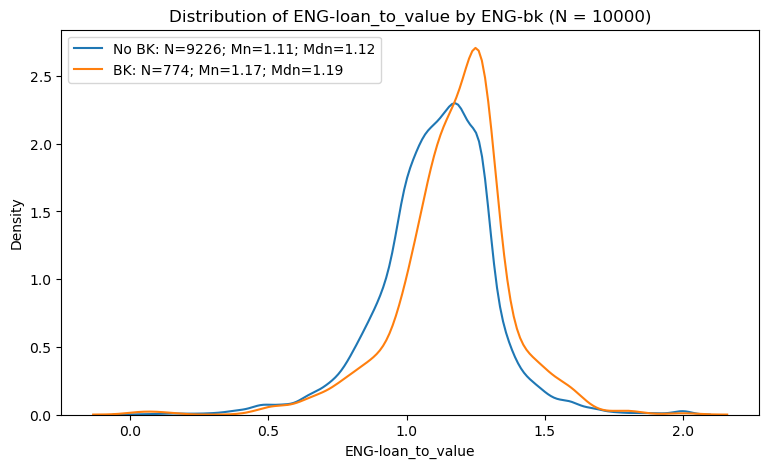

100%|██████████| 2/2 [00:00<00:00, 23.55it/s]


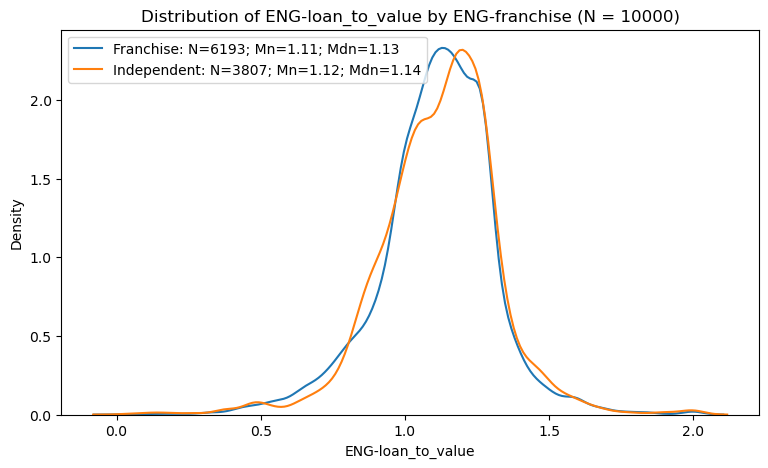

100%|██████████| 2/2 [00:00<00:00, 23.28it/s]


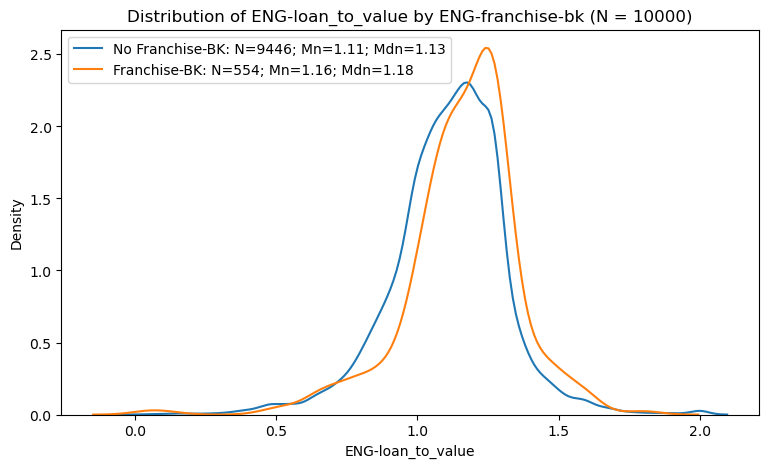

In [17]:
str_col = 'ENG-loan_to_value'
plot_distribution(
    df=df,
    str_col=str_col,
)
for str_iv in list_str_iv:
    plot_dv_by_iv(
        df=df,
        str_col_dv=str_col,
        str_col_iv=str_iv,
    )

#### Income

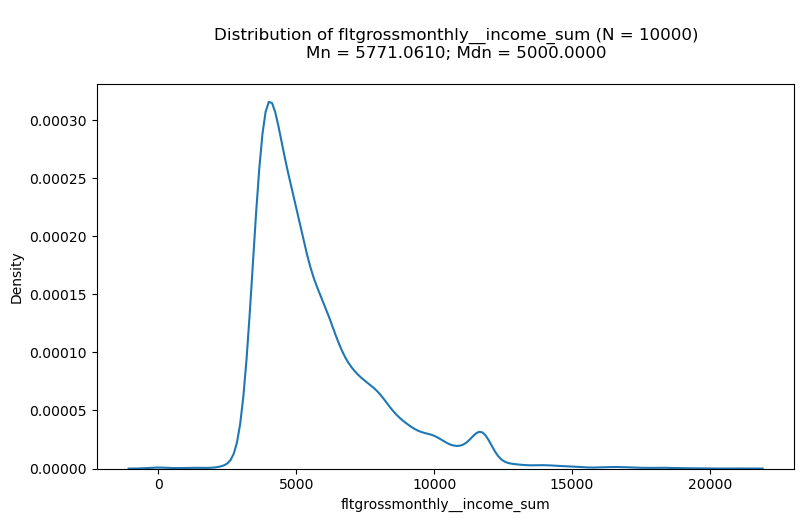

100%|██████████| 2/2 [00:00<00:00, 22.20it/s]


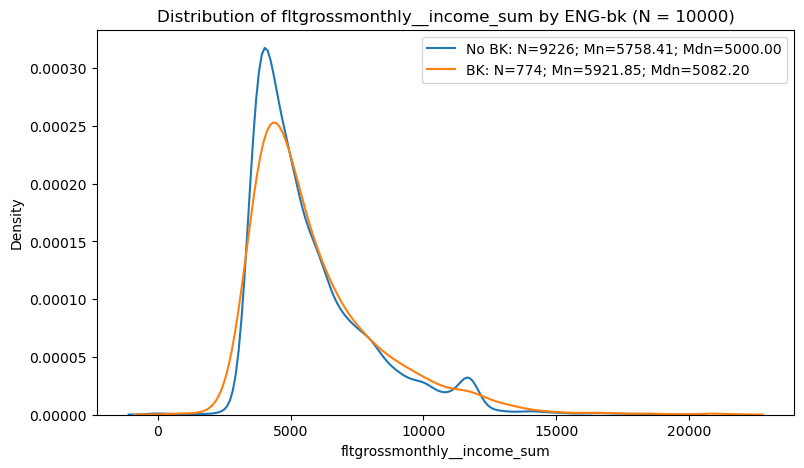

100%|██████████| 2/2 [00:00<00:00, 21.97it/s]


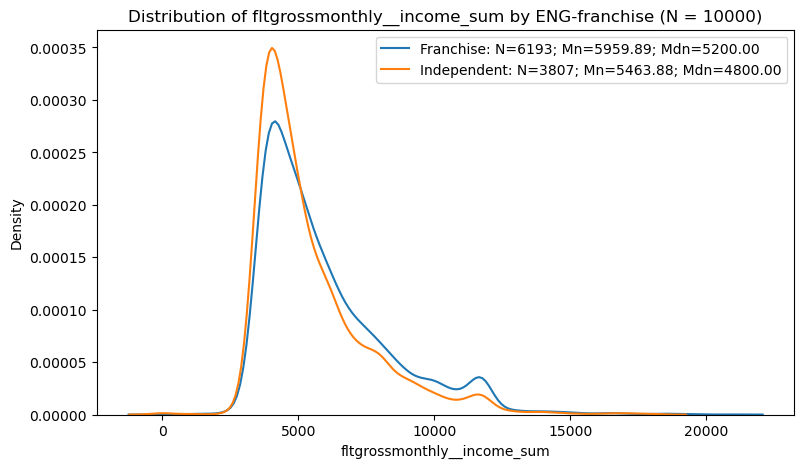

100%|██████████| 2/2 [00:00<00:00, 22.38it/s]


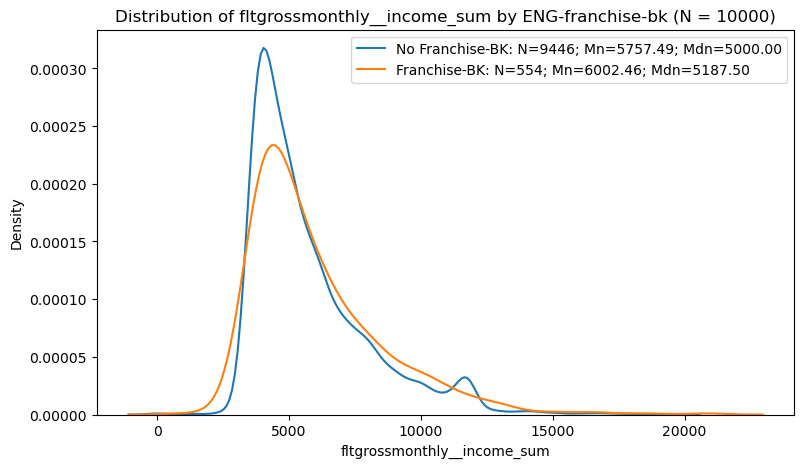

In [18]:
str_col = 'fltgrossmonthly__income_sum'
plot_distribution(
    df=df,
    str_col=str_col,
)
for str_iv in list_str_iv:
    plot_dv_by_iv(
        df=df,
        str_col_dv=str_col,
        str_col_iv=str_iv,
    )

#### Miles

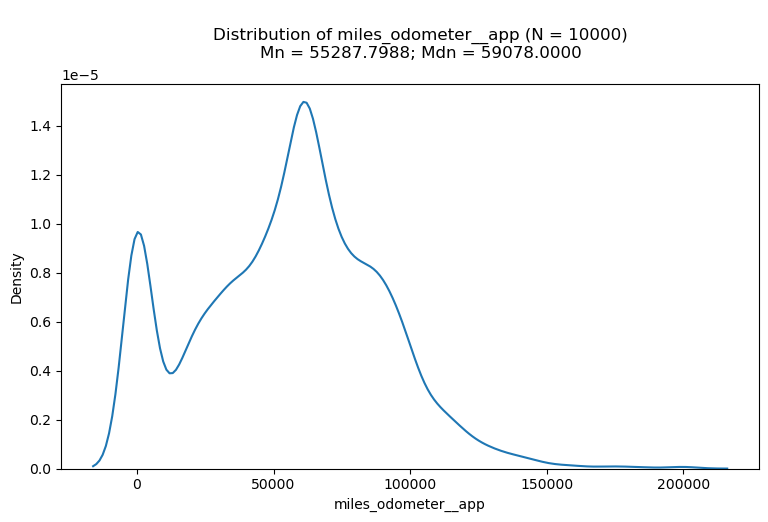

100%|██████████| 2/2 [00:00<00:00, 22.06it/s]


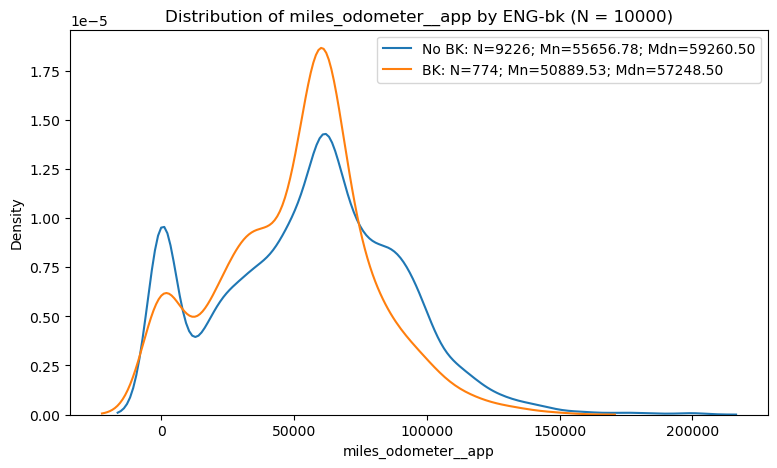

100%|██████████| 2/2 [00:00<00:00, 23.21it/s]


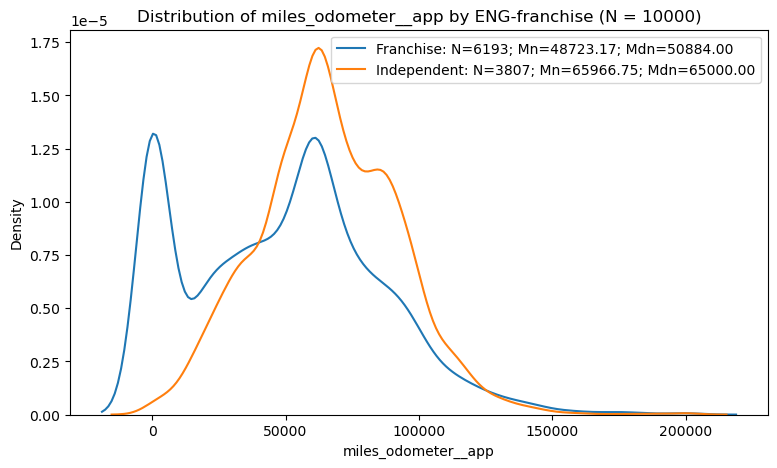

100%|██████████| 2/2 [00:00<00:00, 12.99it/s]


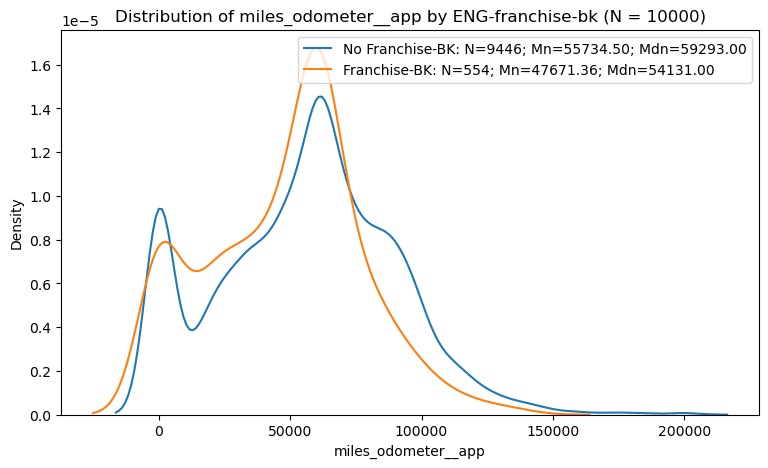

In [19]:
str_col = 'miles_odometer__app'
plot_distribution(
    df=df,
    str_col=str_col,
)
for str_iv in list_str_iv:
    plot_dv_by_iv(
        df=df,
        str_col_dv=str_col,
        str_col_iv=str_iv,
    )